In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys 
sys.path.append('../src')

from cnn import * 
from datas import * 
from train import *

In [3]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [4]:
timepoint = 'DMSO'
bigwig_path = '../data/bws_for_predictor/SPT16_4D_DMSO_Sox2_S40_1_120_sorted.bw'
fasta_path = '../data/GRCm38.primary_assembly.genome.fa'

signal_bins = None
batch_size = 256
epochs = 1000
lr = 1e-3
weight_decay=1e-3
device = 'mps'
weight_decay = 0
patience = 10
sidelines = 0
target_smoothing = False
rc_augment = True

In [5]:
window_left = 1000
window_right = 1000
model_dir = 'models'

In [9]:
if torch.backends.mps.is_available():
    torch.mps.empty_cache()
    print("MPS cache cleared.")

MPS cache cleared.


In [16]:
dataset = SequenceBigWigPeaksDataset(
    fasta_path=str(fasta_path),
    target_bw_path=str(bigwig_path),
    threshold_percentile=99.5,
    signal_bins=signal_bins,
    window_left=window_left,
    window_right=window_right,
)

Discovering peaks in ../data/bws_for_predictor/SPT16_4D_DMSO_Sox2_S40_1_120_sorted.bw...
Using peak threshold: 35.41 (99.5th percentile)
Discovered 14067 peaks.


### Sanity check

In [17]:
len(dataset)

14067

In [18]:
rand_idx = int(np.random.rand() * len(dataset))
x, y = dataset[rand_idx]
x.shape, y.shape, y.sum()

(torch.Size([4, 2000]), torch.Size([2000]), tensor(7376.7725))

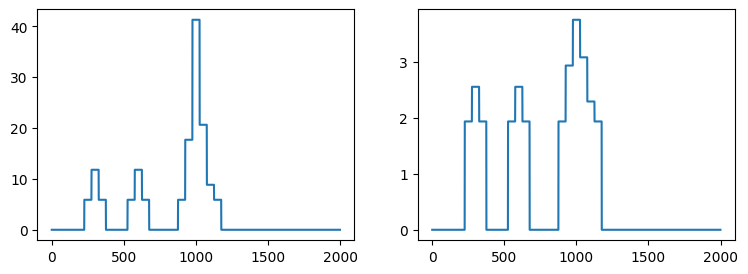

In [19]:
fig, axs = plt.subplots(1, 2, figsize=(9, 3))
_ = axs[0].plot(y.numpy())
_ = axs[1].plot(torch.log1p(y).numpy()) 

In [20]:
from torch.utils.data import DataLoader

loader = DataLoader(dataset, batch_size=256, num_workers=1, shuffle=False)

tot_counts = []
for _, y_batch in loader:
    tot_counts.append(y_batch.numpy())

tot_counts = np.vstack(tot_counts)
tot_counts.shape

(14067, 2000)

'DMSO'

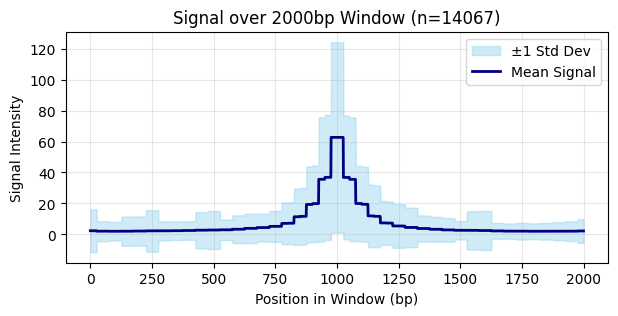

In [21]:
mean_line = np.mean(tot_counts, axis=0)
std_line = np.std(tot_counts, axis=0)
x = np.arange(len(mean_line))

plt.figure(figsize=(7, 3))

plt.fill_between(x, mean_line - std_line, mean_line + std_line, 
                 color='skyblue', alpha=0.4, label='±1 Std Dev')

plt.plot(x, mean_line, color='navy', lw=2, label='Mean Signal')

plt.title(f"Signal over {len(mean_line)}bp Window (n={tot_counts.shape[0]})")
plt.xlabel("Position in Window (bp)")
plt.ylabel("Signal Intensity")
plt.legend()
plt.grid(True, alpha=0.3)

timepoint

### Training

In [22]:
# real training
config = TrainConfig(
    lr=lr,
    weight_decay=weight_decay,
    epochs=epochs,
    device=device,
    patience=patience,
    loss_type='bpnet',
    min_profile=2000,
    sidelines=sidelines,
    target_smoothing=target_smoothing,
    rc_augment=rc_augment
)

model = train_cnn_regressor(
    dataset=dataset,
    batch_size=batch_size,
    config=config,
)

Receptive field: 535 bp (Sequence length: 2000 bp)


Epoch 1/1000 - train: 211463 | val: 121241 (counts: 1183, profile: 120058)
Epoch 2/1000 - train: 116145 | val: 117970 (counts: 636, profile: 117334)
Epoch 3/1000 - train: 114393 | val: 116728 (counts: 640, profile: 116088)
Epoch 4/1000 - train: 113334 | val: 115780 (counts: 693, profile: 115087)
Epoch 5/1000 - train: 112534 | val: 115115 (counts: 649, profile: 114466)
Epoch 6/1000 - train: 111811 | val: 114161 (counts: 629, profile: 113532)
Epoch 7/1000 - train: 111082 | val: 113403 (counts: 644, profile: 112758)
Epoch 8/1000 - train: 110312 | val: 112735 (counts: 620, profile: 112115)
Epoch 9/1000 - train: 109634 | val: 112109 (counts: 608, profile: 111501)
Epoch 10/1000 - train: 109282 | val: 111656 (counts: 664, profile: 110992)
Epoch 11/1000 - train: 108629 | val: 111753 (counts: 601, profile: 111152)
Epoch 12/1000 - train: 108509 | val: 110841 (counts: 618, profile: 110222)
Epoch 13/1000 - train: 107950 | val: 110662 (counts: 594, profile: 110067)
Epoch 14/1000 - train: 107676 | v

In [23]:
import time
from pathlib import Path

date = time.strftime("%m%d")
model_name = f'seq_{timepoint}_{date}'
output_model_path = Path(f'../models/{model_name}.pt')

model.save_model(output_model_path)
model_name

'seq_DMSO_0515'

In [24]:
import os 
os.makedirs('../models/loaders', exist_ok=True)

torch.save(model.val_loader, f'../models/loaders/{model_name}_val.pt')
torch.save(model.test_loader, f'../models/loaders/{model_name}_test.pt')
torch.save(model.train_loader, f'../models/loaders/{model_name}_train.pt')

### Evaluate

In [25]:
%matplotlib inline
import os
import torch
from torch.utils.data import DataLoader

In [27]:
model_name = 'seq_DMSO_0515'

results_dir = f'../results/{model_name}'
os.makedirs(results_dir, exist_ok=True)

In [28]:
model = BPNetModel.load_model(f'../models/{model_name}.pt')
model.test_loader = torch.load(f'../models/loaders/{model_name}_test.pt', weights_only=False)
model.train_loader = torch.load(f'../models/loaders/{model_name}_train.pt', weights_only=False)
model.val_loader = torch.load(f'../models/loaders/{model_name}_val.pt', weights_only=False)

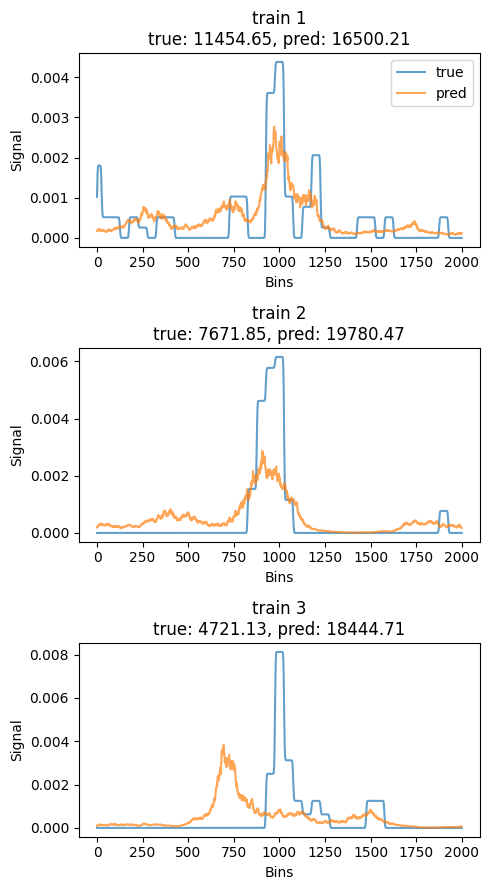

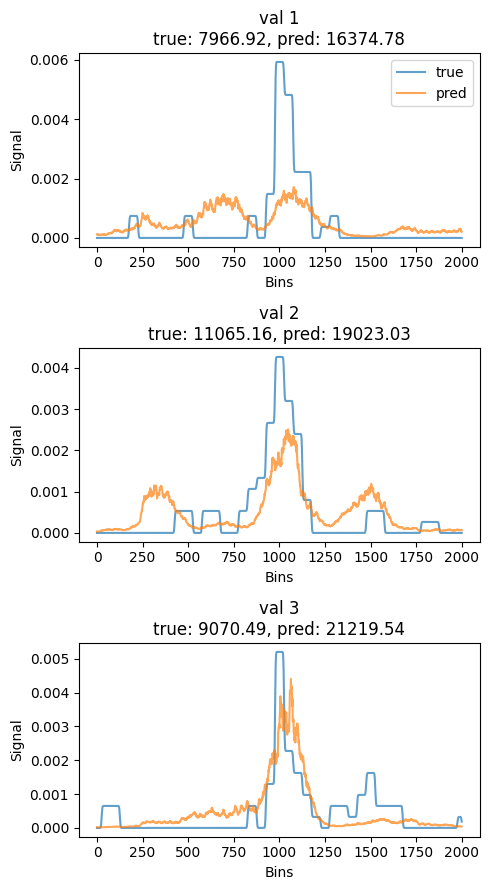

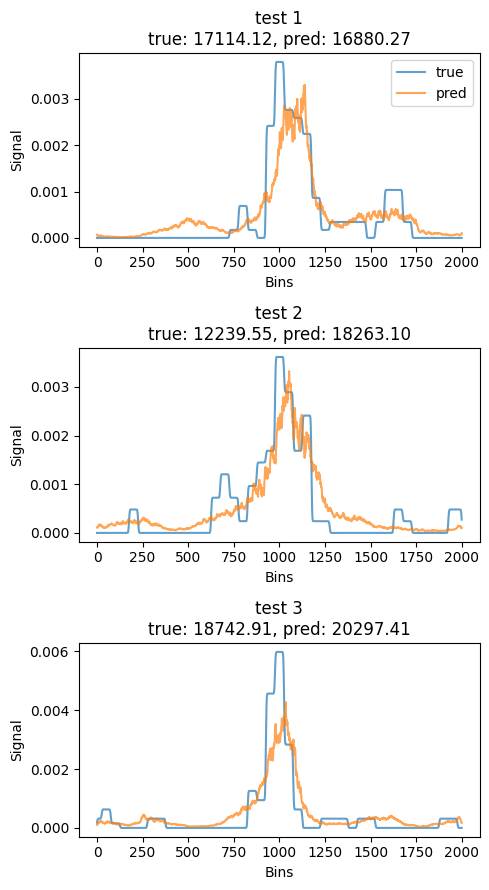

In [29]:
visualize_split_predictions(
    model,
    device='cpu',
    n_examples_per_split=3,
    smooth_true=True
)

Evaluating Train split...
Evaluating Validation split...
Evaluating Test split...
Evaluating Uniform split...
Evaluating Permuted split...
Evaluating Gaussian split...


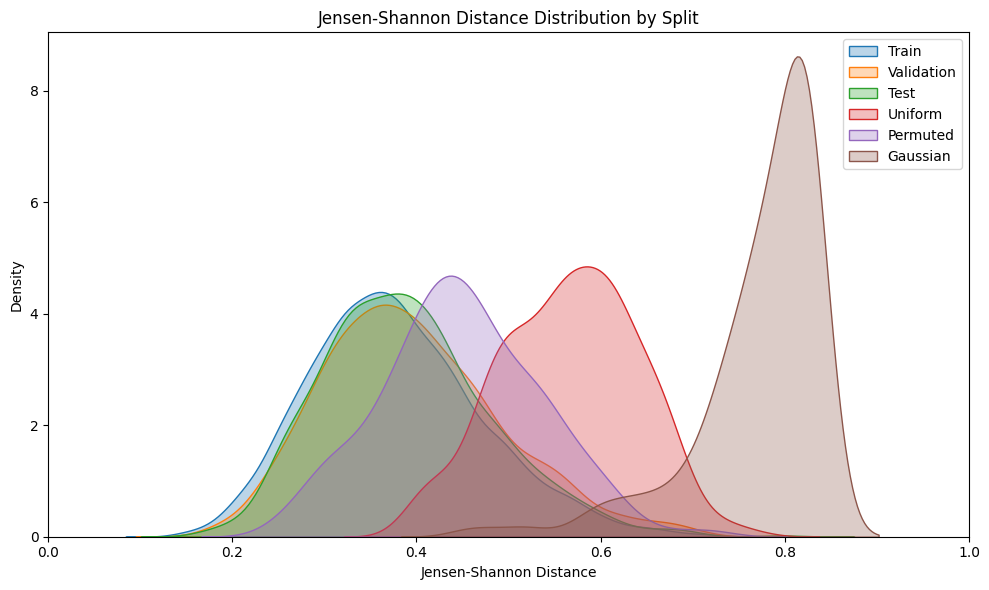

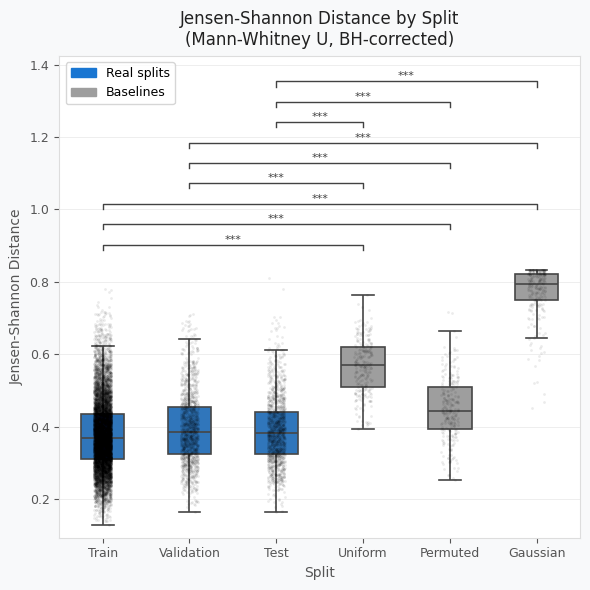

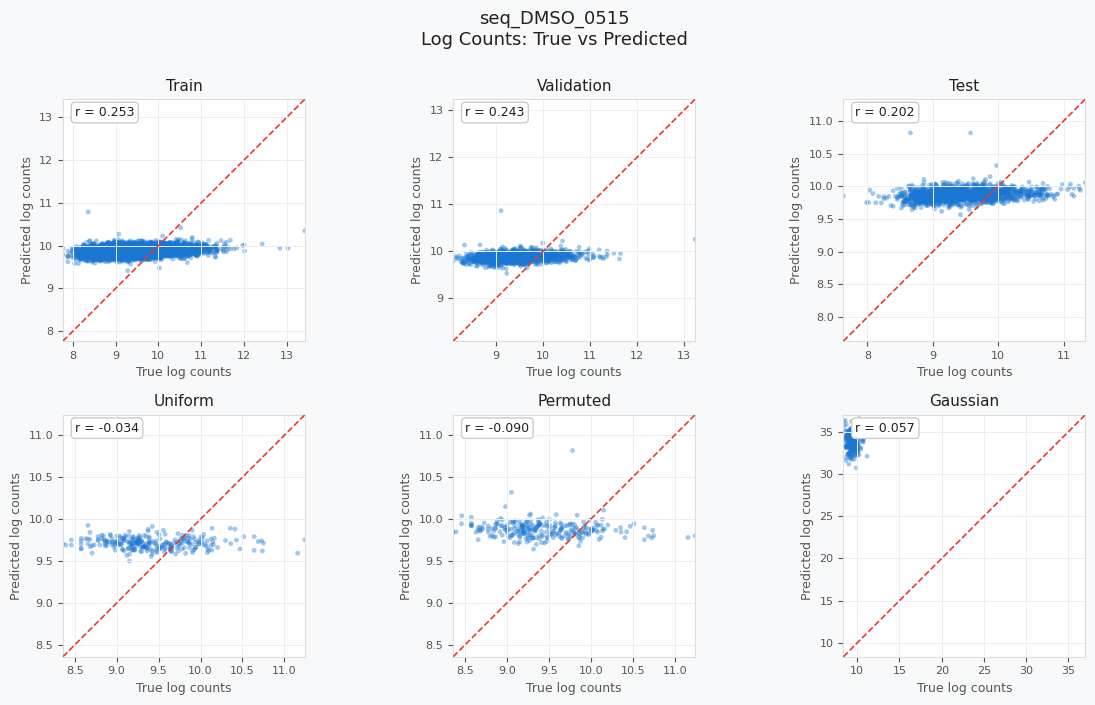

In [30]:
from evaluate import evaluate_baselines, plot_counts_correlation, evaluate_baselines_sig
%matplotlib inline

df_corr, loader_metrics = evaluate_baselines(model, results_dir=results_dir)
df_stats = evaluate_baselines_sig(loader_metrics, results_dir=results_dir)

plot_counts_correlation(loader_metrics, model_name=model_name, results_dir=results_dir)

### Track motifs

In [31]:
import os
import torch

os.environ['NUMBA_NUM_THREADS'] = '1'
os.environ['OMP_NUM_THREADS'] = '1'
os.environ['MKL_NUM_THREADS'] = '1'
os.environ['KMP_WARNINGS'] = '0'

if torch.backends.mps.is_available():
    torch.mps.empty_cache()

import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="captum")
    

In [32]:
loader = DataLoader(dataset, batch_size=256, num_workers=1, shuffle=False)
len(loader.dataset)

14067

Indexing intervals by total signal...
Running Knockout Test (n=100)...
Running Implant Test (n=100)...

ISM DIAGNOSTIC SUMMARY
Knockout (n=100):
  Mean Motif Delta: -122.89
  Mean Ctrl Delta:   -10.33
  Wilcoxon p-val:    1.32e-08

Implant (n=100):
  Mean Motif Delta: +105.38
  Mean Rand Delta:  -82.10
  Wilcoxon p-val:    1.16e-16



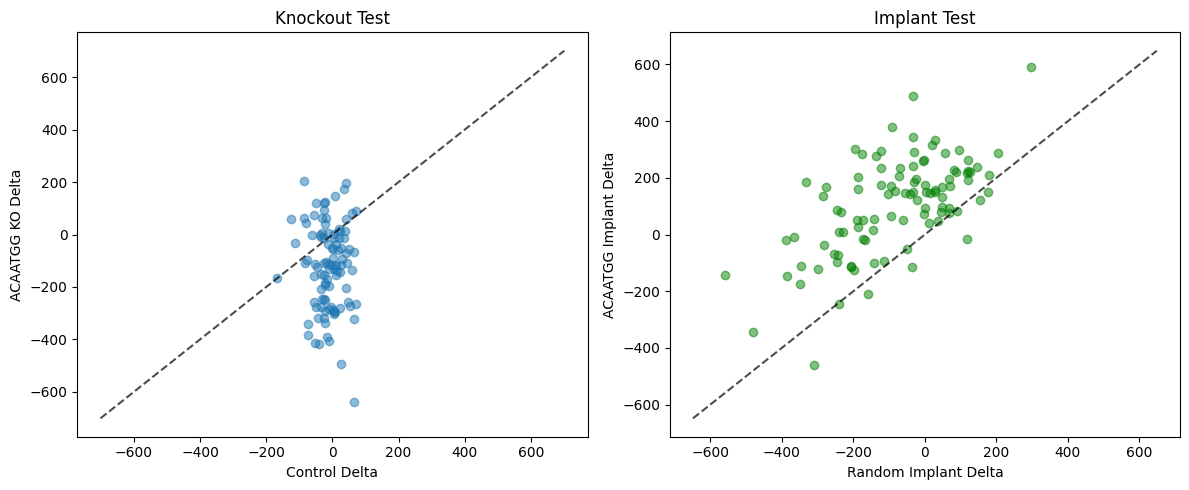

In [33]:
from check import run_ism_diagnostic, plot_ism_diagnostic
%matplotlib inline

# motif = "CATTGTT" 
motif = "ACAATGG"

ko_df, imp_df = run_ism_diagnostic(
    model, 
    dataset, 
    motif_seq=motif, 
    device='mps', 
    n_high=100, 
    n_low=100
)

fig = plot_ism_diagnostic(ko_df, imp_df, motif_name=motif)

Scanning sequences and extracting attributions for SOX2...
  Processed 100 sequences
  Processed 200 sequences
  Processed 300 sequences
  Processed 400 sequences
  Processed 500 sequences


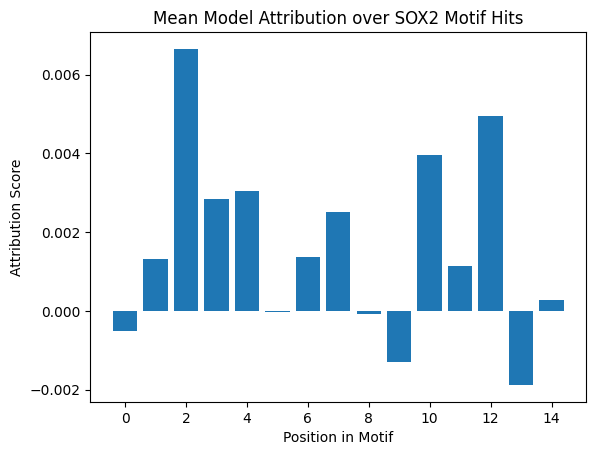

In [34]:
from motif_match import match_motifs_to_attributions
%matplotlib inline 

meme_path = '../data/JASPAR2024_CORE_vertebrates.meme'

attrs, scores = match_motifs_to_attributions(
    model, 
    loader=loader, 
    meme_path=meme_path, 
    motif_name="SOX2", 
    device='mps', 
    head="profile", 
    n_seqs=500, 
    min_counts=model.min_profile
)

mean_attr = attrs.sum(axis=1).mean(axis=0) # Sum over ACGT channels, mean across sequences

plt.bar(range(len(mean_attr)), mean_attr)
plt.title("Mean Model Attribution over SOX2 Motif Hits")
plt.xlabel("Position in Motif")
plt.ylabel("Attribution Score")
plt.show()


Scanning sequences and extracting attributions for PATZ1...
  Processed 100 sequences
  Processed 200 sequences
  Processed 300 sequences
  Processed 400 sequences
  Processed 500 sequences


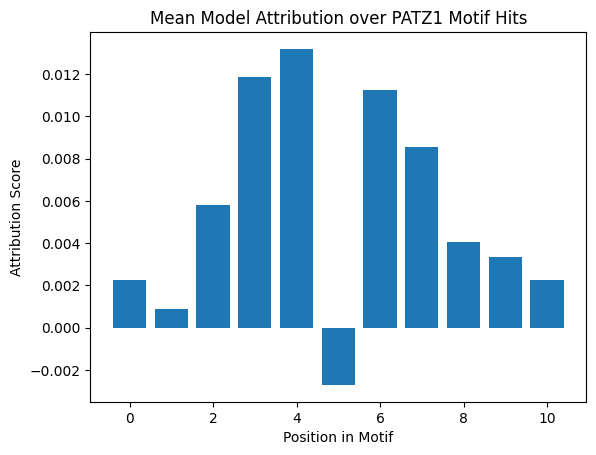

In [35]:
from motif_match import match_motifs_to_attributions
%matplotlib inline 

meme_path = '../data/JASPAR2024_CORE_vertebrates.meme'

attrs, scores = match_motifs_to_attributions(
    model, 
    loader=loader, 
    meme_path=meme_path, 
    motif_name="PATZ1", 
    device='mps', 
    head="profile", 
    n_seqs=500, 
    min_counts=model.min_profile
)

mean_attr = attrs.sum(axis=1).mean(axis=0) 

plt.bar(range(len(mean_attr)), mean_attr)
plt.title("Mean Model Attribution over PATZ1 Motif Hits")
plt.xlabel("Position in Motif")
plt.ylabel("Attribution Score")
plt.show()


In [ ]:
from motif import discover_motifs

pos, neg = discover_motifs(
    model, 
    loader=model.test_loader, 
    device='mps', 
    sliding_window_size=12,
    min_counts=model.min_profile, 
    save_path=f'{results_dir}/modisco_profile.h5', 
)

Generating attributions on mps...
  kept 1408 sequences for attribution
  skipped 0 (below min_counts=2000)
  skipped 0 (low complexity, max_base_fraction>0.55)
Executing MoDISco-lite on 1408 sequences (window=12, flank=4, FDR=0.25, leiden=100)...
Using 27692 positive seqlets


In [ ]:
print(f'modisco report -i {results_dir}/modisco_profile.h5 -o {results_dir}/report/  -m ../data/JASPAR2024_CORE_vertebrates.meme')

modisco report -i ../results/seq_DMSO_0514/modisco_profile.h5 -o ../results/seq_DMSO_0514/report/  -m ../data/JASPAR2024_CORE_vertebrates.meme
